# Step 2 — Sentiment Analysis (VADER)

**Project:** Customer Review Intelligence — NLP-Powered Product & Reputation Analytics

Classifies every review as **positive / neutral / negative** using VADER
(Valence Aware Dictionary and sEntiment Reasoner) — a lexicon/rule-based
sentiment tool that runs fully offline (no model downloads, no API calls).
It's well-suited to short, informal text like product reviews.

**Reads:** `data\raw\amazon_reviews.csv`
**Writes:** `data\processed\reviews_with_sentiment.csv`

Run cells in order.


## Setup

In [ ]:
# If not already installed:
# !pip install vaderSentiment pandas matplotlib seaborn

In [3]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [12]:
"""
sentiment_analysis.py
----------------------
Step 2: Sentiment Analysis using VADER (lexicon/rule-based, works fully offline).

Reads:  data/raw/amazon_reviews.csv
Writes: data/processed/reviews_with_sentiment.csv
"""

from pathlib import Path

import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ---------------------------------------------------------------------
# PROJECT ROOT — anchored so this works regardless of where Jupyter is launched
# ---------------------------------------------------------------------
BASE_DIR = Path(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
df = pd.read_csv(RAW_DIR / "amazon_reviews.csv")
print(f"Loaded {len(df)} reviews.")

# ---------------------------------------------------------------------
# Run VADER sentiment
# ---------------------------------------------------------------------
analyzer = SentimentIntensityAnalyzer()


def score_review(title, text):
    """Combines title + body (titles often carry strong signal, e.g.
    'Would not recommend') and returns VADER's compound score plus a
    positive/neutral/negative label."""
    full_text = f"{title}. {text}"
    scores = analyzer.polarity_scores(str(full_text))
    compound = scores["compound"]
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return pd.Series({
        "sentiment_score": compound,
        "sentiment_label": label,
        "vader_pos": scores["pos"],
        "vader_neu": scores["neu"],
        "vader_neg": scores["neg"],
    })


sentiment_cols = df.apply(lambda row: score_review(row["review_title"], row["review_text"]), axis=1)
df = pd.concat([df, sentiment_cols], axis=1)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
out_path = PROCESSED_DIR / "reviews_with_sentiment.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------
print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts(normalize=True).round(3))

print("\nSentiment vs star rating (sanity check — should align diagonally):")
print(pd.crosstab(df["rating"], df["sentiment_label"], normalize="index").round(2))

print("\nMost negative reviews (lowest compound score):")
print(df.sort_values("sentiment_score").head(5)[["product_name", "rating", "review_text", "sentiment_score"]].to_string())

print("\nMost positive reviews (highest compound score):")
print(df.sort_values("sentiment_score", ascending=False).head(5)[["product_name", "rating", "review_text", "sentiment_score"]].to_string())


Loaded 6500 reviews.
Saved: C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\processed\reviews_with_sentiment.csv

Sentiment distribution:
sentiment_label
positive    0.703
negative    0.267
neutral     0.030
Name: proportion, dtype: float64

Sentiment vs star rating (sanity check — should align diagonally):
sentiment_label  negative  neutral  positive
rating                                      
1                    0.92     0.02      0.06
2                    0.80     0.04      0.16
3                    0.39     0.12      0.49
4                    0.06     0.03      0.91
5                    0.00     0.00      1.00

Most negative reviews (lowest compound score):
                     product_name  rating                                                                                                                                                                                                                                     

## Visualize: overall sentiment split

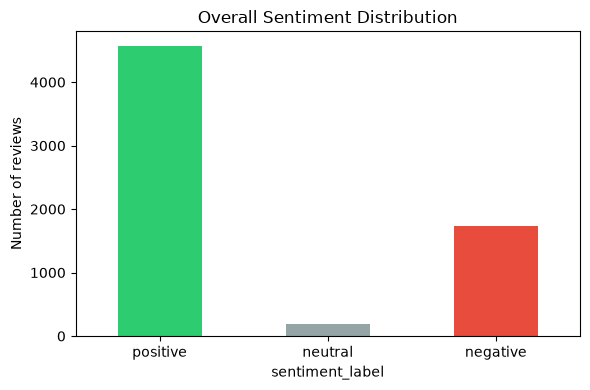

In [13]:
import matplotlib.pyplot as plt

counts = df['sentiment_label'].value_counts()
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
plt.figure(figsize=(6,4))
counts.reindex(['positive','neutral','negative']).plot(
    kind='bar', color=[colors[c] for c in ['positive','neutral','negative']]
)
plt.title('Overall Sentiment Distribution')
plt.ylabel('Number of reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Sanity check: does sentiment align with star ratings?
This is the key validation step — if 5-star reviews aren't mostly 'positive', something's wrong.

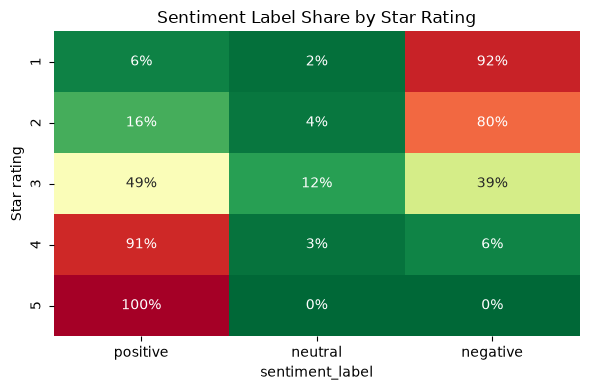

In [14]:
import seaborn as sns

pivot = pd.crosstab(df['rating'], df['sentiment_label'], normalize='index')
pivot = pivot.reindex(columns=['positive','neutral','negative'])
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', cbar=False)
plt.title('Sentiment Label Share by Star Rating')
plt.ylabel('Star rating')
plt.tight_layout()
plt.show()

## Sentiment trend over time (all products)

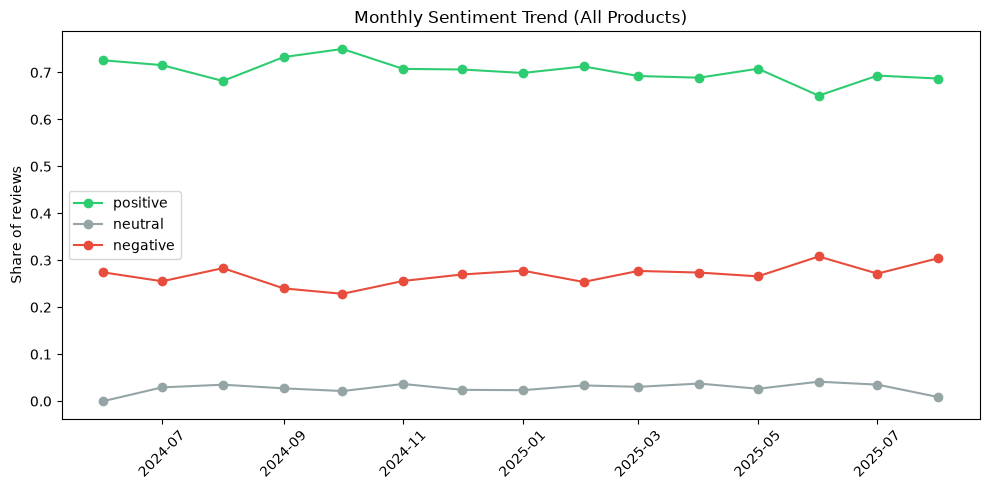

In [15]:
df['review_date'] = pd.to_datetime(df['review_date'])
df['review_month'] = df['review_date'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby(['review_month', 'sentiment_label']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)

plt.figure(figsize=(10,5))
for label, color in colors.items():
    plt.plot(monthly_pct.index, monthly_pct[label], label=label, color=color, marker='o')
plt.title('Monthly Sentiment Trend (All Products)')
plt.ylabel('Share of reviews')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Which products have the worst sentiment right now?
Quick preview before the full risk-scoring step (Step 4).

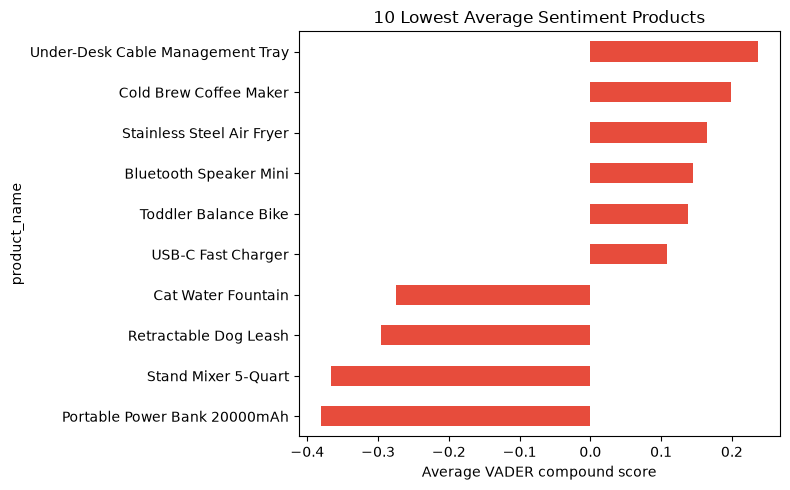

In [16]:
product_sentiment = (
    df.groupby('product_name')['sentiment_score']
    .mean()
    .sort_values()
    .head(10)
)
product_sentiment.plot(kind='barh', color='#e74c3c', figsize=(8,5))
plt.title('10 Lowest Average Sentiment Products')
plt.xlabel('Average VADER compound score')
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
df_check = pd.read_csv(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\raw\amazon_reviews.csv")
strong_words = df_check['review_text'].str.contains('terrible|awful|horrible|disgusting', case=False).sum()
print(f"Reviews with strong negative words: {strong_words}")

Reviews with strong negative words: 1000
